# Test Lensing models

In [1]:
# including packages
using PyPlot
using PSFModels

In [2]:
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG
using Jens:LensPlots as Jplots

# Lens instance

In [3]:
image_para = Dict(
    :num => 50,
    :deltap => 0.09,
    :redshift => 1.0,
    :bkg_noise => 0.5,
    :exp_time => 90,
)

Dict{Symbol, Real} with 5 entries:
  :num       => 50
  :deltap    => 0.09
  :bkg_noise => 0.5
  :redshift  => 1.0
  :exp_time  => 90

In [4]:
x = range(-2, 2, 51)
xg, yg = LU.ndgrid(x,x)

([-2.0 -2.0 … -2.0 -2.0; -1.92 -1.92 … -1.92 -1.92; … ; 1.92 1.92 … 1.92 1.92; 2.0 2.0 … 2.0 2.0], [-2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0; … ; -2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0])

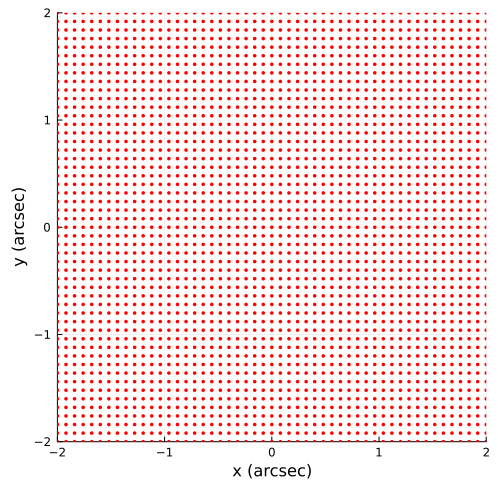

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(xg, yg, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()\nPyPlot.clf()\n"

In [5]:
pc = Jplots.LensCanvas(;  xlims=(-2,2), ylims=(-2,2),
                    size=(500,500))
Jplots.PlotPoints!(pc, xg, yg)
display(pc)

"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(xg, yg, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()
PyPlot.clf()
"""

# SIS

In [6]:
using Jens.LensModel:SISreal as SISreal
using Jens.LensModel:SIS as SIS
# using Jens.LensModel:SIS as SIS

In [7]:
LensParaDict = Dict(:theta_E=>1., :xcentre => 0.1, :ycentre => .2);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIS, LensKwargs=LensParaDict)

([-1.3095242533174993 -1.2962523392888428 … -1.2263710773213776 -1.2407433976347035; -1.2436691387148373 -1.2301743008083883 … -1.1586189617462974 -1.1734069147753936; … ; 1.2825756528484398 1.2686193379281623 … 1.1932083767267683 1.2089974027880273; 1.3463801296539077 1.3325892969523048 … 1.258649124559489 1.2740473160941734], [-1.2766444558564278 -1.209549980615403 … 1.2863610728536998 1.3492086265440315; -1.2634020322636843 -1.1960245137196948 … 1.2716953535661542 1.3347190329681724; … ; -1.2294870528937185 -1.161248899125112 … 1.2331419824011216 1.296810618142005; -1.2431769922308404 -1.1753101629152032 … 1.2488823653906953 1.3122553520892168])

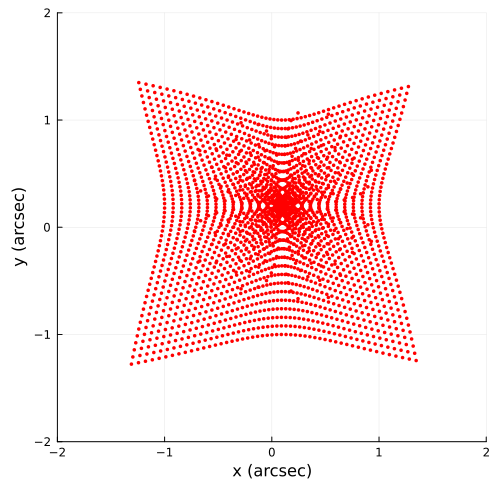

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [8]:
sisc = Jplots.LensCanvas(;  xlims=(-2,2), ylims=(-2,2),
                    size=(500,500))
Jplots.PlotPoints!(sisc, betax, betay)
display(sisc)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

In [9]:
m = SIS.LensPotential(xg, yg; LensParaDict...);

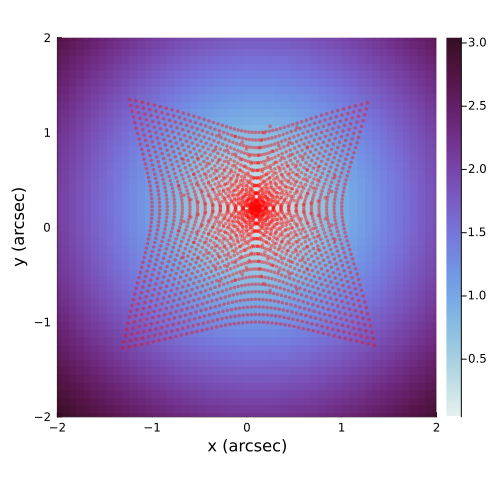

"PyPlot.contourf(xg, yg, m)\ngcf()"

In [10]:
plane = Jplots.LensCanvas(; xlims=(-2,2), ylims=(-2,2),
                    size=(500,500))
Jplots.PlotPlane!(plane, xg, yg, m, colormap=:dense)
Jplots.PlotPoints!(plane, betax, betay, alpha=0.4)
display(plane)

"""PyPlot.contourf(xg, yg, m)
gcf()"""

# benchmark comparison

In [11]:
using BenchmarkTools

In [12]:
LensParaDict = Dict(:theta_E=>1., :xcentre => 0.1, :ycentre => .2);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIS, LensKwargs=LensParaDict)

([-1.3095242533174993 -1.2962523392888428 … -1.2263710773213776 -1.2407433976347035; -1.2436691387148373 -1.2301743008083883 … -1.1586189617462974 -1.1734069147753936; … ; 1.2825756528484398 1.2686193379281623 … 1.1932083767267683 1.2089974027880273; 1.3463801296539077 1.3325892969523048 … 1.258649124559489 1.2740473160941734], [-1.2766444558564278 -1.209549980615403 … 1.2863610728536998 1.3492086265440315; -1.2634020322636843 -1.1960245137196948 … 1.2716953535661542 1.3347190329681724; … ; -1.2294870528937185 -1.161248899125112 … 1.2331419824011216 1.296810618142005; -1.2431769922308404 -1.1753101629152032 … 1.2488823653906953 1.3122553520892168])

In [13]:
LensParaDict = Dict(:theta_E=>1., :xcentre => 0.1, :ycentre => .2);
betax, betay = LB.LensPlane(xg, yg; LensModel=SISreal, LensKwargs=LensParaDict)

([-1.3095242533174993 -1.2962523392888428 … -1.2263710773213776 -1.2407433976347035; -1.2436691387148373 -1.2301743008083883 … -1.1586189617462974 -1.1734069147753936; … ; 1.2825756528484398 1.2686193379281623 … 1.1932083767267683 1.2089974027880273; 1.3463801296539077 1.3325892969523048 … 1.258649124559489 1.2740473160941734], [-1.2766444558564278 -1.209549980615403 … 1.2863610728536998 1.3492086265440315; -1.2634020322636843 -1.1960245137196948 … 1.2716953535661542 1.3347190329681724; … ; -1.2294870528937185 -1.161248899125112 … 1.2331419824011216 1.296810618142005; -1.2431769922308404 -1.1753101629152032 … 1.2488823653906953 1.3122553520892168])

In [14]:
@benchmark  LB.LensPlane(xg, yg; LensModel=SIS, LensKwargs=LensParaDict)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  15.409 μs …  3.253 ms  ┊ GC (min … max): 0.00% … 97.36%
 Time  (median):     17.493 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   20.685 μs ± 51.898 μs  ┊ GC (mean ± σ):  8.23% ±  4.21%

   ▃▆██▇▆▅▄▂▁▁▁                                               ▂
  ▇███████████████▇▆▇▆▇▆▆▅▆▅▅▅▄▅▂▅▂▃▄▄▄▄▄▅▅▆▆▄▆▆▇▇▇▆█▇████▇▇▇ █
  15.4 μs      Histogram: log(frequency) by time      41.2 μs <

 Memory estimate: 219.52 KiB, allocs estimate: 65.

In [15]:
@benchmark  LB.LensPlane(xg, yg; LensModel=SISreal, LensKwargs=LensParaDict)

BenchmarkTools.Trial: 10000 samples with 1 evaluation per sample.
 Range (min … max):  15.158 μs …  1.203 ms  ┊ GC (min … max): 0.00% … 91.82%
 Time  (median):     17.523 μs              ┊ GC (median):    0.00%
 Time  (mean ± σ):   18.853 μs ± 31.749 μs  ┊ GC (mean ± σ):  5.41% ±  3.18%

              ▄▅▇█▇▆▄▃▁                                        
  ▂▁▁▂▂▂▂▃▄▅▇██████████▇▅▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂ ▃
  15.2 μs         Histogram: frequency by time        23.8 μs <

 Memory estimate: 219.52 KiB, allocs estimate: 65.

These tests show the SIS(::Real) shares the silimar speed with SIS(::Float64).

# Shear

In [16]:
using Jens.LensModel:Shear as Shear

In [17]:
LensParaDict = Dict(:gamma1=>0.1, :gamma2=>0.1,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=Shear, LensKwargs=LensParaDict)

([-1.5899999999999999 -1.5979999999999999 … -1.982 -1.99; -1.5179999999999998 -1.5259999999999998 … -1.91 -1.918; … ; 1.938 1.93 … 1.5459999999999998 1.5379999999999998; 2.01 2.002 … 1.6179999999999999 1.6099999999999999], [-1.99 -1.902 … 2.322 2.41; -1.998 -1.91 … 2.314 2.402; … ; -2.382 -2.294 … 1.93 2.018; -2.39 -2.302 … 1.922 2.01])

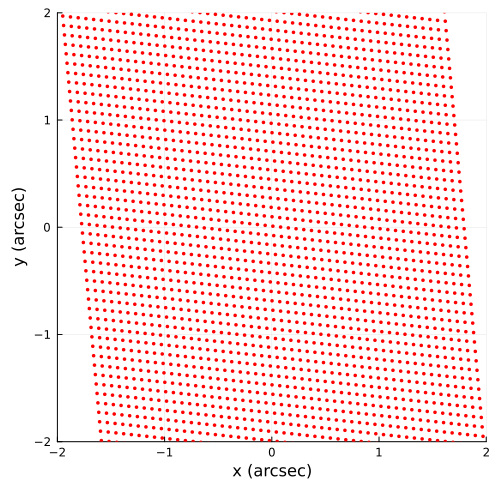

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [18]:
shearc = Jplots.LensCanvas(;  xlims=(-2,2), ylims=(-2,2),
                    size=(500,500))
Jplots.PlotPoints!(shearc, betax, betay)
display(shearc)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

# Major-axes NIE model

In [19]:
using Jens.LensModel:NIEkappa as NIEkappa

In [20]:
# NIE model 
LensParaDict = Dict(:b => 1., :s => 0.1,
 :q => 0.6, :varphi =>  - pi/6. ,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NIEkappa, LensKwargs=LensParaDict)

([-1.1118564403645022 -1.0985088576790023 … -1.2320087965170559 -1.2532226160838948; -1.0457318633373158 -1.0321536163116565 … -1.1731448311305481 -1.1946562540869632; … ; 1.2531742412513962 1.231137291506011 … 1.0698049999756778 1.0838831022068813; 1.3088977644449944 1.2870287933243634 … 1.1341076113297257 1.148001311037504], [-1.0122399607995953 -0.9474874272977827 … 1.0764339466605755 1.1327444042104038; -0.9989115064459131 -0.9338898933864929 … 1.0548105099648541 1.1116404941165718; … ; -1.0579368550297579 -0.9995058138568871 … 0.898884924957736 0.9647262155842908; -1.0795473818008128 -1.0218094001472902 … 0.9130492192140813 0.9785364807596826])

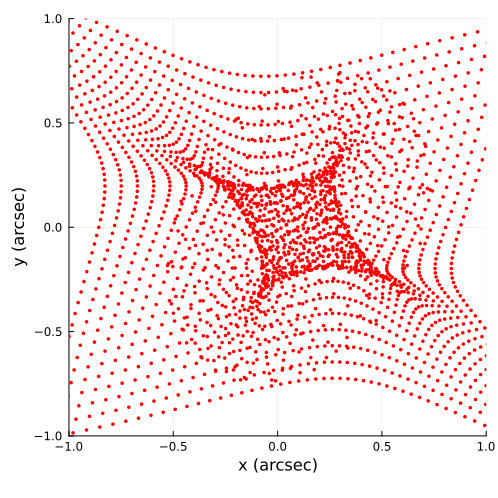

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1, )\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [21]:
niec = Jplots.LensCanvas(;  xlims=(-1,1), ylims=(-1,1),
                    size=(500,500))
Jplots.PlotPoints!(niec, betax, betay)
display(niec)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

In [22]:
# NIE model 1
LensParaDict1 = Dict{Symbol, Float64}(:b => 0.6, :s => 0.1,
 :q => 0.7, :varphi => pi/3. ,
  :xcentre => -.5, :ycentre => 0.5)
# NIE model 2
LensParaDict2 = Dict{Symbol, Float64}(:b => 0.8, :s => 0.1,
 :q => 0.5, :varphi =>  -pi/6. ,
  :xcentre => 0.5, :ycentre => -0.5)
betax2, betay2 = LB.MultiLensRayShootingPosition(xg, yg; 
            LensModel = [NIEkappa, NIEkappa],
            LensKwargs = [LensParaDict1, LensParaDict2])

([[-2.0 -2.0 … -2.0 -2.0; -1.92 -1.92 … -1.92 -1.92; … ; 1.92 1.92 … 1.92 1.92; 2.0 2.0 … 2.0 2.0], [-1.6639039873935664 -1.6538358595806162 … -1.4533299835778655 -1.463919622451596; -1.6012805544513402 -1.5913361732343492 … -1.3850003064064604 -1.395898002384024; … ; 1.3832519867948796 1.3765617864336748 … 1.3041421016330843 1.313246772786847; 1.4561747592841412 1.4496012350527232 … 1.378474565332116 1.3871906320446812], [-0.7385335003603815 -0.7194186677047368 … -0.8806550044284513 -0.9055067645157776; -0.679229892076487 -0.6598794828856205 … -0.8279467520626453 -0.853112628796025; … ; 0.8958577706084068 0.857061885189444 … 0.8277159486051995 0.8408350581828914; 0.9310223158560241 0.8922961081676208 … 0.8812705731219204 0.8945406949592968]], [[-2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0; … ; -2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0], [-1.4460051565590377 -1.3727090916481353 … 1.4502334913309052 1.5183109188007242; -1.4361853233438695 -1.3625066925682587 … 1.439378714861535 1.507

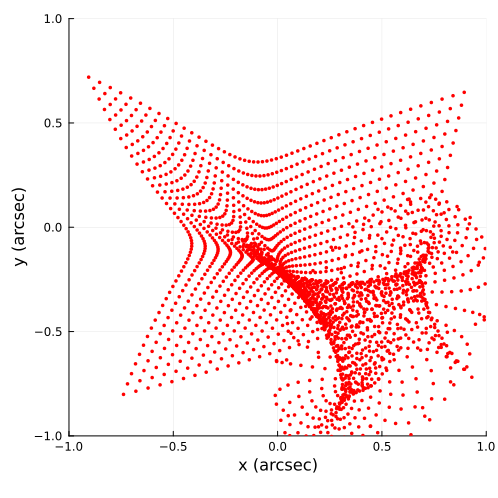

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax2, betay2, s=1, )\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [23]:
mc = Jplots.LensCanvas(;  xlims=(-1,1), ylims=(-1,1),
                 size=(500,500))
SourcePlane = Jplots.PlotPoints!(mc, betax2[end], betay2[end])
display(mc)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax2, betay2, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

## Decouple multiple lenses 2

In [24]:
bx1, by1 = LB.LensPlane(xg, yg; LensModel=NIEkappa, LensKwargs=LensParaDict1)
bx2, by2 = LB.LensPlane(bx1, by1; LensModel=NIEkappa, LensKwargs=LensParaDict2)

([-0.7385335003603815 -0.7194186677047368 … -0.8806550044284513 -0.9055067645157776; -0.679229892076487 -0.6598794828856205 … -0.8279467520626453 -0.853112628796025; … ; 0.8958577706084068 0.857061885189444 … 0.8277159486051995 0.8408350581828914; 0.9310223158560241 0.8922961081676208 … 0.8812705731219204 0.8945406949592968], [-0.8010364306568561 -0.7506325014552719 … 0.6661808114296153 0.7193794680261892; -0.7858373052283583 -0.7355691381737139 … 0.6407262314325808 0.6945244109187988; … ; -0.6807100841191925 -0.6405111389155951 … 0.5685793914889448 0.6304601688928291; -0.7188219257317365 -0.6806948493147423 … 0.5849629675642651 0.6467128207790231])

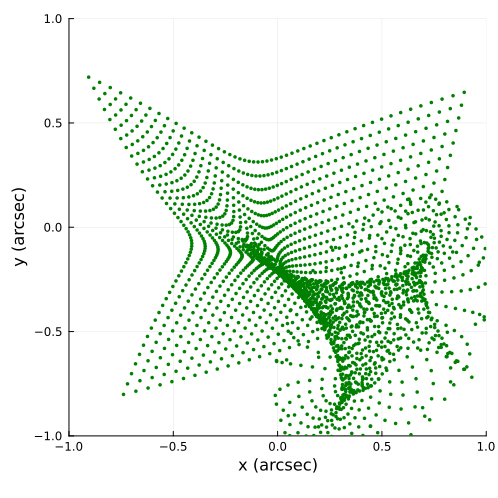

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax2, betay2, s=1, )\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [25]:
dmc = Jplots.LensCanvas(;  xlims=(-1,1), ylims=(-1,1),
        size=(500,500))
SourcePlane = Jplots.PlotPoints!(dmc, bx2, by2, color="green")
display(dmc)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax2, betay2, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

# NIE model

In [26]:
using Jens.LensModel:NIE as NIE

In [27]:
# NIE model 
LensParaDict = Dict(:theta_E => 1.5, :s_scale => 0.1,
 :e1 => 0.2, :e2 =>  0.3,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NIE, LensKwargs=LensParaDict)

([-1.2611204635175777 -1.2353799731040866 … -1.0023906573196308 -1.0157200130996271; -1.2073699419172719 -1.1814691320849584 … -0.9366480560712138 -0.9501740851627423; … ; 0.9897155246086258 0.9757792072538316 … 1.2520509043097832 1.2780320354855579; 1.0532891886661389 1.0395008175218967 … 1.3028853659184443 1.3288936333548405], [-0.9866130629042043 -0.9358384284331864 … 0.7506386480733345 0.8147625292048681; -0.9611975049251429 -0.9096050162267086 … 0.7370710169756669 0.8014740105099476; … ; -0.7675363262715138 -0.7023002714909916 … 0.8434562711740674 0.8974374153019851; -0.7812217059850064 -0.7163428032821078 … 0.8699651503106596 0.9229332240748129])

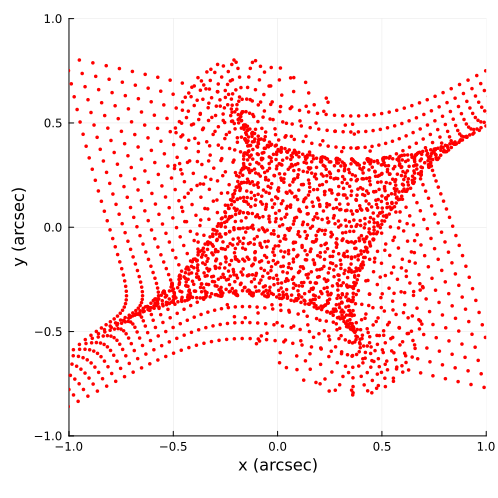

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [28]:
niec = Jplots.LensCanvas(;  xlims=(-1,1), ylims=(-1,1),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(niec, betax, betay )
display(niec)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

# Point mass

In [29]:
using Jens.LensModel:PointMass as PointMass

In [30]:
LensParaDict = Dict(:theta_E => 0.3, :xcentre => 0., :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=PointMass, LensKwargs=LensParaDict)

([-1.9775 -1.9765820149875104 … -1.9765820149875104 -1.9775; -1.89751873438801 -1.8965625 … -1.8965625 -1.89751873438801; … ; 1.89751873438801 1.8965625 … 1.8965625 1.89751873438801; 1.9775 1.9765820149875104 … 1.9765820149875104 1.9775], [-1.9775 -1.89751873438801 … 1.89751873438801 1.9775; -1.9765820149875104 -1.8965625 … 1.8965625 1.9765820149875104; … ; -1.9765820149875104 -1.8965625 … 1.8965625 1.9765820149875104; -1.9775 -1.89751873438801 … 1.89751873438801 1.9775])

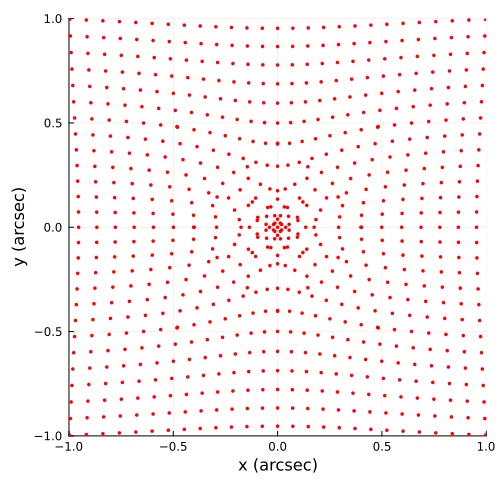

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [31]:
pmc = Jplots.LensCanvas(;  xlims=(-1,1), ylims=(-1,1),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(pmc, betax, betay )
display(pmc)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

# SIE model

In [32]:
using Jens.LensModel:SIE as SIE

In [33]:
LensParaDict = Dict(:theta_E => 1., :s => 0.1,
 :e1 => 0.1, :e2 =>  0.2,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIE, LensKwargs=LensParaDict)

([-1.3715390116941926 -1.3545088214170464 … -1.2569322556027858 -1.2680274577939026; -1.3088089157842653 -1.2915096888208977 … -1.1882807384913145 -1.19957462474573; … ; 1.2313562706376882 1.219628212148839 … 1.3382988040922372 1.3561049317342506; 1.2981205166080851 1.2865534084162584 … 1.398822294255682 1.4164580761430259], [-1.3023189787063856 -1.2413675265170132 … 1.1410591189208996 1.2083798520213276; -1.2853461939575153 -1.2240100280962687 … 1.1297564665140243 1.1972934767147803; … ; -1.1688280929968364 -1.1006270085768357 … 1.1794735591926817 1.2420156066271046; -1.1803329124911197 -1.1124194554650089 … 1.1974599461329816 1.2594767958053508])

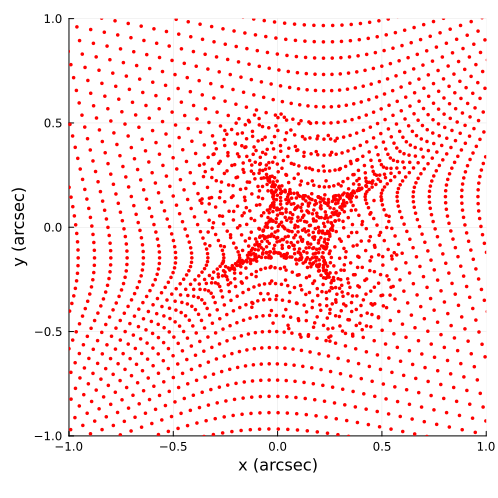

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [34]:
siec = Jplots.LensCanvas(;  xlims=(-1,1), ylims=(-1,1),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(siec, betax, betay )
display(siec)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

# EPL model

In [35]:
using Jens.LensModel:EPL as EPL

In [36]:
LensParaDict = Dict(:theta_E => 1., :gamma => 0.05,
:e1 => 0.1, :e2 =>  0.2,
  :xcentre => 0.1, :ycentre => 0.0);
betax, betay = LB.LensPlane(xg, yg; LensModel=EPL, LensKwargs=LensParaDict)

([2.5152237215541833 2.351970658475489 … -0.8530031424018609 -0.9304596390754842; 2.421394807047249 2.258252253236594 … -0.9248368485373615 -1.0029804734657835; … ; 1.3630289748695097 1.2828349324729929 … -1.8514805560566168 -2.014086204339479; 1.3026103027238238 1.2232953283843777 … -1.9294985631496209 -2.092369857576858], [-0.8606123890903086 -1.0004155986752126 … -10.074098895149325 -10.517605746653759; -0.733546093541023 -0.8740057665733716 … -9.660248193322085 -10.097206047231381; … ; 9.08638990356167 8.665781019936542 … 0.5749001344520852 0.4310623553120785; 9.48381337543972 9.056668095294926 … 0.6918846067321043 0.5497005879366792])

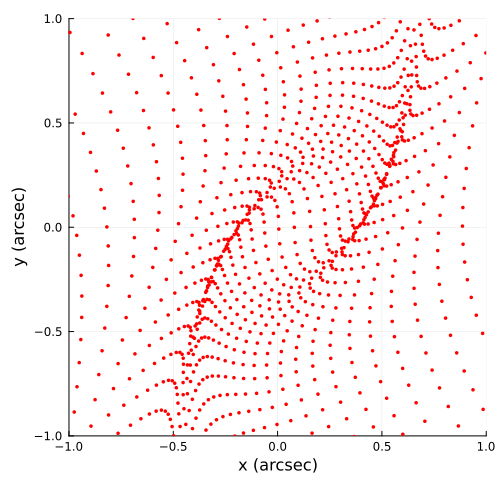

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [37]:
eplc = Jplots.LensCanvas(;  xlims=(-1,1), ylims=(-1,1),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(eplc, betax, betay )
display(eplc)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

# NFW (spherical)

In [38]:
using Jens.LensModel:NFW as NFW

In [39]:
LensParaDict = Dict(:Rs=>2.0, :alpha_Rs=>0.5,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NFW, LensKwargs=LensParaDict)

([-1.6341045693112684 -1.6268961803758708 … -1.6268961803758708 -1.6341045693112684; -1.5607461176895552 -1.5534171177598712 … -1.5534171177598712 -1.5607461176895552; … ; 1.579475398285358 1.5718956149945704 … 1.5718956149945704 1.579475398285358; 1.651604285697111 1.6441147040386643 … 1.6441147040386643 1.651604285697111], [-1.651528161248827 -1.5788765077722247 … 1.5788765077722247 1.651528161248827; -1.6443030868213417 -1.5715647851975012 … 1.5715647851975012 1.6443030868213417; … ; -1.625797140972921 -1.5527690004338326 … 1.5527690004338326 1.625797140972921; -1.6332676691548536 -1.560368543028545 … 1.560368543028545 1.6332676691548536])

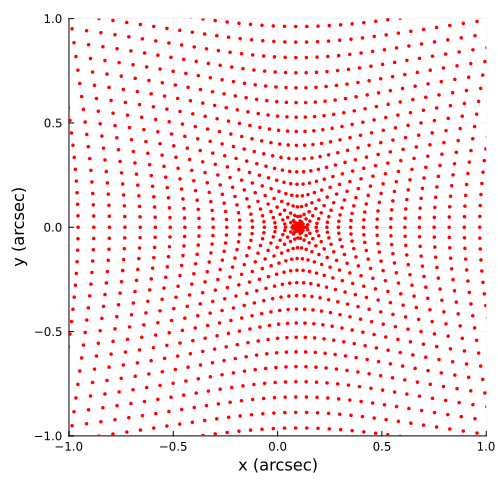

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [40]:
nfwc = Jplots.LensCanvas(;  xlims=(-1,1), ylims=(-1,1),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(nfwc, betax, betay )
display(nfwc)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

# NFW (elliptical)

In [41]:
using Jens.LensModel:NFWE as NFWE

In [42]:
LensParaDict = Dict(:Rs=>1.5, :alpha_Rs=>1., :e1=>0.1, :e2=>0.2,
  :xcentre => 0.4, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NFWE, LensKwargs=LensParaDict)

([-1.2829218984886104 -1.2606473266030727 … -1.3334485331663324 -1.3452966211972308; -1.2202014707086501 -1.197389719526575 … -1.2589983095829527 -1.2709510483564348; … ; 1.3553805073572942 1.3432014627775364 … 1.4365555561604797 1.4605390143465602; 1.4242266657479172 1.4119708506600221 … 1.4866812911803402 1.5110308699124488], [-1.2992191280684149 -1.240594840662283 … 1.2408720903958859 1.314607400315851; -1.2803019864633987 -1.2211374752228847 … 1.23118917697641 1.3050376176935459; … ; -1.2003352887006025 -1.1245974509534977 … 1.0317199649777922 1.1000640198358247; -1.21144086830693 -1.135961134213363 … 1.0489137062454257 1.1160942648417345])

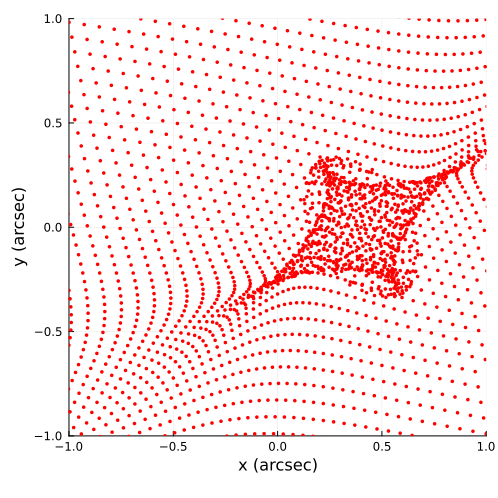

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [43]:
nfwec = Jplots.LensCanvas(;  xlims=(-1,1), ylims=(-1,1),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(nfwec, betax, betay )
display(nfwec)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

# Gaussian

In [44]:
using Jens.LensModel:Gaussian as GaussianModel

In [45]:
LensParaDict = Dict(:kappa0=>2., :q=>0.5, :sigma=>0.5, :varphi=>pi/6,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=GaussianModel, LensKwargs=LensParaDict)

([-1.2890311417916767 -1.267762440898344 … -1.8267297527524187 -1.8402786515296599; -1.2018398176223377 -1.179415168940918 … -1.7554836444730495 -1.7691472022180064; … ; 1.794690225740864 1.7809050088634018 … 1.1641170351843586 1.1891833194681518; 1.8638725626603114 1.850104789185009 … 1.2491810667768646 1.2732457020453545], [-2.2198613390956083 -2.129174540662528 … 2.5533008815023592 2.6248587823830984; -2.242710150724541 -2.152904475182529 … 2.567288083498471 2.6380950008006088; … ; -2.67144547045893 -2.602683586673515 … 2.217934032240019 2.3048084677750844; -2.658084834237177 -2.5884765531865455 … 2.1909881953487074 2.279161134152433])

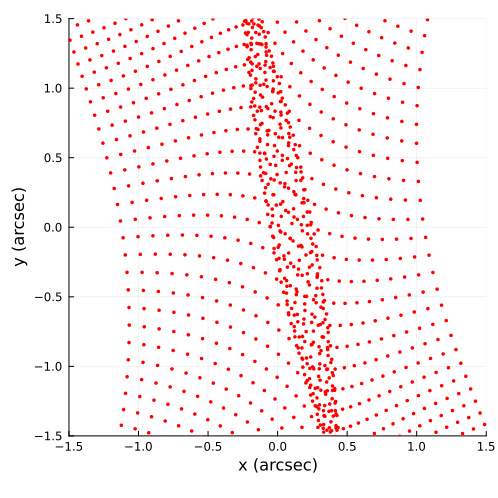

"FigLnes = PyPlot.figure(figsize=(6, 6))\nPyPlot.scatter(betax, betay, s=1)\nPyPlot.xlabel(\"x (pix)\")\nPyPlot.ylabel(\"y (pix)\")\ngcf()"

In [46]:
gc = Jplots.LensCanvas(;  xlims=(-1.5,1.5), ylims=(-1.5,1.5),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(gc, betax, betay )
display(gc)


"""FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()"""

In [47]:
kappalist = [0.5, 0.4, 0.3, 0.2, 0.02]
philist = [pi/4, pi, pi/3, -pi/3, -pi]
qlist = [0.5, 0.4, 0.3, 0.4, 0.2]
betax, betay = xg, yg
for i in 1:length(kappalist)
    LensParaDict = Dict(:kappa0=>kappalist[i], :q=>qlist[i], :sigma=>0.5, :varphi=>philist[i],:xcentre => 0.01, :ycentre => .01);
    betax, betay = LB.LensPlane(betax, betay; LensModel=GaussianModel, LensKwargs=LensParaDict)
end

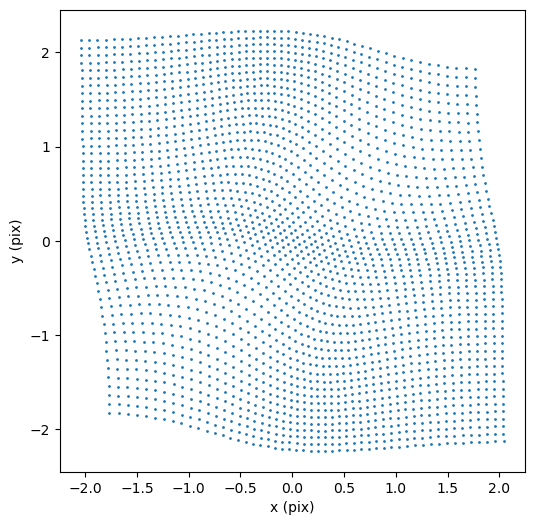

In [48]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay , s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Combined Lens

In [49]:
using Jens.LensModel:ComLens as ComLens

## recomaned to use CombinedLens struct

In [50]:
combinelens = ComLens.CombinedLens(
    NFW      => (Rs=0.8, alpha_Rs=0.4, xcentre=-0.6, ycentre=-0.3),
    NIEkappa => (b=1.0, s=0.05, q=0.7, varphi=pi/6),
    Shear    => (gamma1=0.03, gamma2=-0.05),
)
beta_x, beta_y = LB.LensPlane(xg, yg; LensModel=combinelens, LensKwargs=Dict())

([-1.0751628408366 -1.0436400831236314 … -0.8166016200084003 -0.832745356617383; -1.0248370230817128 -0.9929308854725278 … -0.7607568746504021 -0.7770735178798349; … ; 0.6705560320571666 0.6548194326242054 … 0.982195621094016 1.01092662667187; 0.7325436096634979 0.7172456210653109 … 1.0381508936449342 1.0664715794294284], [-1.035208961364384 -0.9769611405351899 … 0.6767337468770054 0.7434243005069794; -1.0038895571066582 -0.9448434928544596 … 0.6602067388524537 0.7274832744881925; … ; -0.8448566008127469 -0.7824836930853227 … 1.0178270437647465 1.0773705554648876; -0.8602234290203303 -0.798148631802374 … 1.0466304461386577 1.105620603596396])

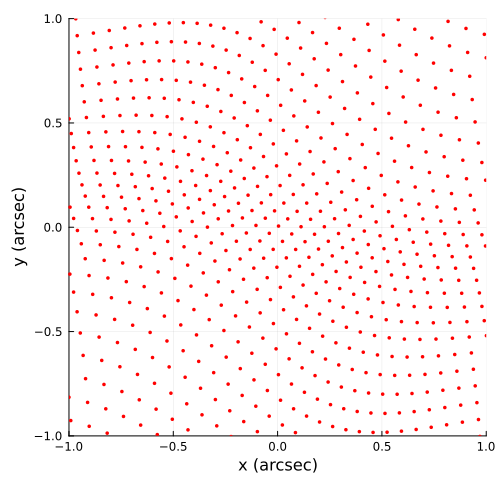

In [51]:
clc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(clc, betax, betay )
display(clc)

## Or you can use mudule-like format

In [52]:
# The module form of complex lens is fixed with parameters,
# which is use for quick lens projection, rather than parameters fitting

mylens = ComLens.MyLens(
    NFW      => (Rs=1.0, alpha_Rs=0.5,  xcentre=-0.5, ycentre=0.3),
    NIEkappa => (b=0.6, s=0.1, q=0.5, varphi=pi/4, xcentre=0.5, ycentre=-0.3),
    Shear    => (gamma1=0.05, gamma2=-0.03, xcentre=0., ycentre=0.),
)
ComLens.LensPara(mylens)

Main.CombinedLens  —  3 components:
  [1] NFW → Dict(:Rs => 1.0, :ycentre => 0.3, :alpha_Rs => 0.5, :xcentre => -0.5)
  [2] NIEkappa → Dict(:b => 0.6, :s => 0.1, :varphi => 0.7853981633974483, :q => 0.5, :xcentre => 0.5, :ycentre => -0.3)
  [3] Shear → Dict(:gamma2 => -0.03, :gamma1 => 0.05, :ycentre => 0.0, :xcentre => 0.0)


In [53]:
betax, betay = LB.LensPlane(xg, yg; LensModel=mylens, LensKwargs=Dict{Symbol,Float64}()) 

([-1.067181339240639 -1.0436009830320732 … -0.8560729334491957 -0.8703652976093048; -1.0101930914612138 -0.9860929860388434 … -0.7952470321577967 -0.8098134097978642; … ; 0.8535521568598874 0.8392099921479077 … 1.1957832922090683 1.2199293032436611; 0.9139697053694071 0.8999316192468667 … 1.2465757028168967 1.2707830145535892], [-1.438297721515637 -1.3772267228677393 … 0.9920803954473809 1.0620217491795494; -1.4145069813762963 -1.3533431849827553 … 0.9774512782011971 1.0477888978820684; … ; -1.0752896960805338 -1.0051316197083564 … 1.1647517054213379 1.2314055417451464; -1.0892870826960268 -1.0195169051146238 … 1.1892749162217173 1.2552488213164628])

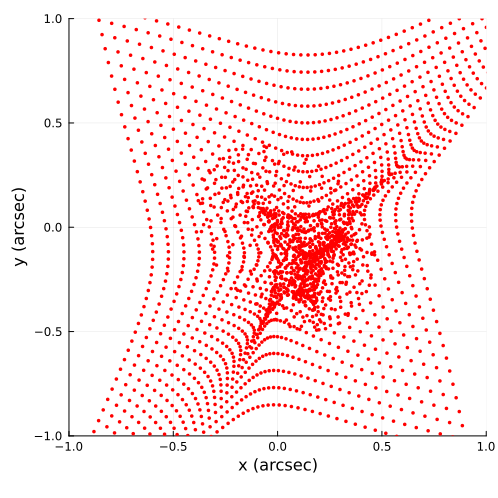

In [54]:
clc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(clc, betax, betay )
display(clc)

## Or

In [55]:
lens = ComLens.JitLens(
    NFW      => (:Rs, :alpha_Rs, :xcentre, :ycentre),
    NIEkappa => (:b, :s, :q, :varphi, :xcentre, :ycentre),
)
params = Dict{Symbol,Float64}(
    :NFW_Rs => 1.0, :NFW_alpha_Rs => 0.5,
    :NFW_xcentre => -0.5, :NFW_ycentre => -0.1,
    :NIEkappa_b => 1.5, :NIEkappa_s => 0.05,
    :NIEkappa_q => 0.7, :NIEkappa_varphi => -pi/4,
    :NIEkappa_xcentre => 0.1, :NIEkappa_ycentre => 0.5,
)
betax, betay = LB.LensPlane(xg, yg; LensModel=lens, LensKwargs=params) 

([-0.48420095973429333 -0.4571562763085464 … -0.3016711702970929 -0.3402058243452566; -0.4351908837869445 -0.4079153221473848 … -0.25273377345605663 -0.292524914388947; … ; 0.6488715185250766 0.6158037920763126 … 0.14684975436591197 0.17801333721929846; 0.6915192130796337 0.6586820902268979 … 0.2047995345336806 0.2349687164532377], [-0.2240950687851142 -0.16442083781972316 … 0.6869205992465037 0.7195570834328147; -0.19730231340976911 -0.13688314304734073 … 0.6476831908220702 0.6804914914642943; … ; -0.3416340900918442 -0.28780754782063944 … 0.4587864561783648 0.5022964151766824; -0.37417113682256975 -0.32118602216194714 … 0.4895823823853309 0.5328172535311575])

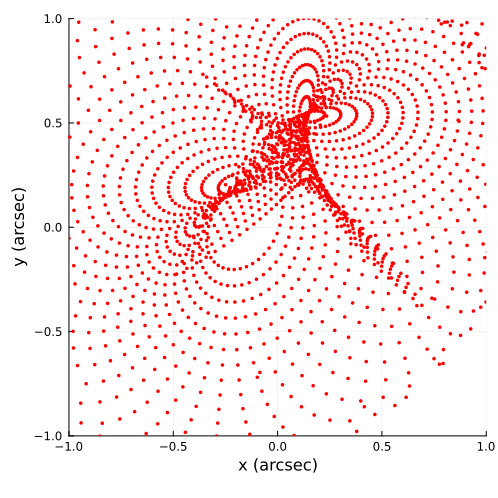

In [56]:
clc = Jplots.LensCanvas(;  xlims=(-1.,1.), ylims=(-1.,1.),
            size=(500,500))
SourcePlane = Jplots.PlotPoints!(clc, betax, betay )
display(clc)